# Printing & Universities Spatial Distribution
Comparison of book printing places and university locations in Europe.

In [1]:
import folium
import json

# Load data
with open('../../DATA/05_external_datasets/books_data.json', 'r') as f:
    books = json.load(f)
with open('../../DATA/05_external_datasets/universities_data.json', 'r') as f:
    univ = json.load(f)

In [19]:
# Create map centered on Europe
m = folium.Map(location=[48, 10], zoom_start=5, tiles='CartoDB positron')

# Add Universities (Indigo)
univ_group = folium.FeatureGroup(name='Universities')
for u in univ:
    folium.CircleMarker(
        location=[u['lat'], u['lon']],
        radius=6,
        popup=f"<b>{u['label']}</b><br>{u['city']}<br>Founded: {u['foundation']}",
        color='#818cf8',
        fill=True,
        fill_opacity=0.7
    ).add_to(univ_group)
univ_group.add_to(m)

# Add Books (Amber)
book_group = folium.FeatureGroup(name='Books')
for b in books:
    folium.CircleMarker(
        location=[b['lat'], b['lon']],
        radius=4,
        popup=f"<b>{b['title']}</b><br>{b['place']}<br>Year: {b['year']}",
        color='#fbbf24',
        fill=True,
        fill_opacity=0.8
    ).add_to(book_group)
book_group.add_to(m)

folium.LayerControl().add_to(m)

# Display map
m


## Static Map (Bright Version)
A non-dynamic version for easy export/printing.

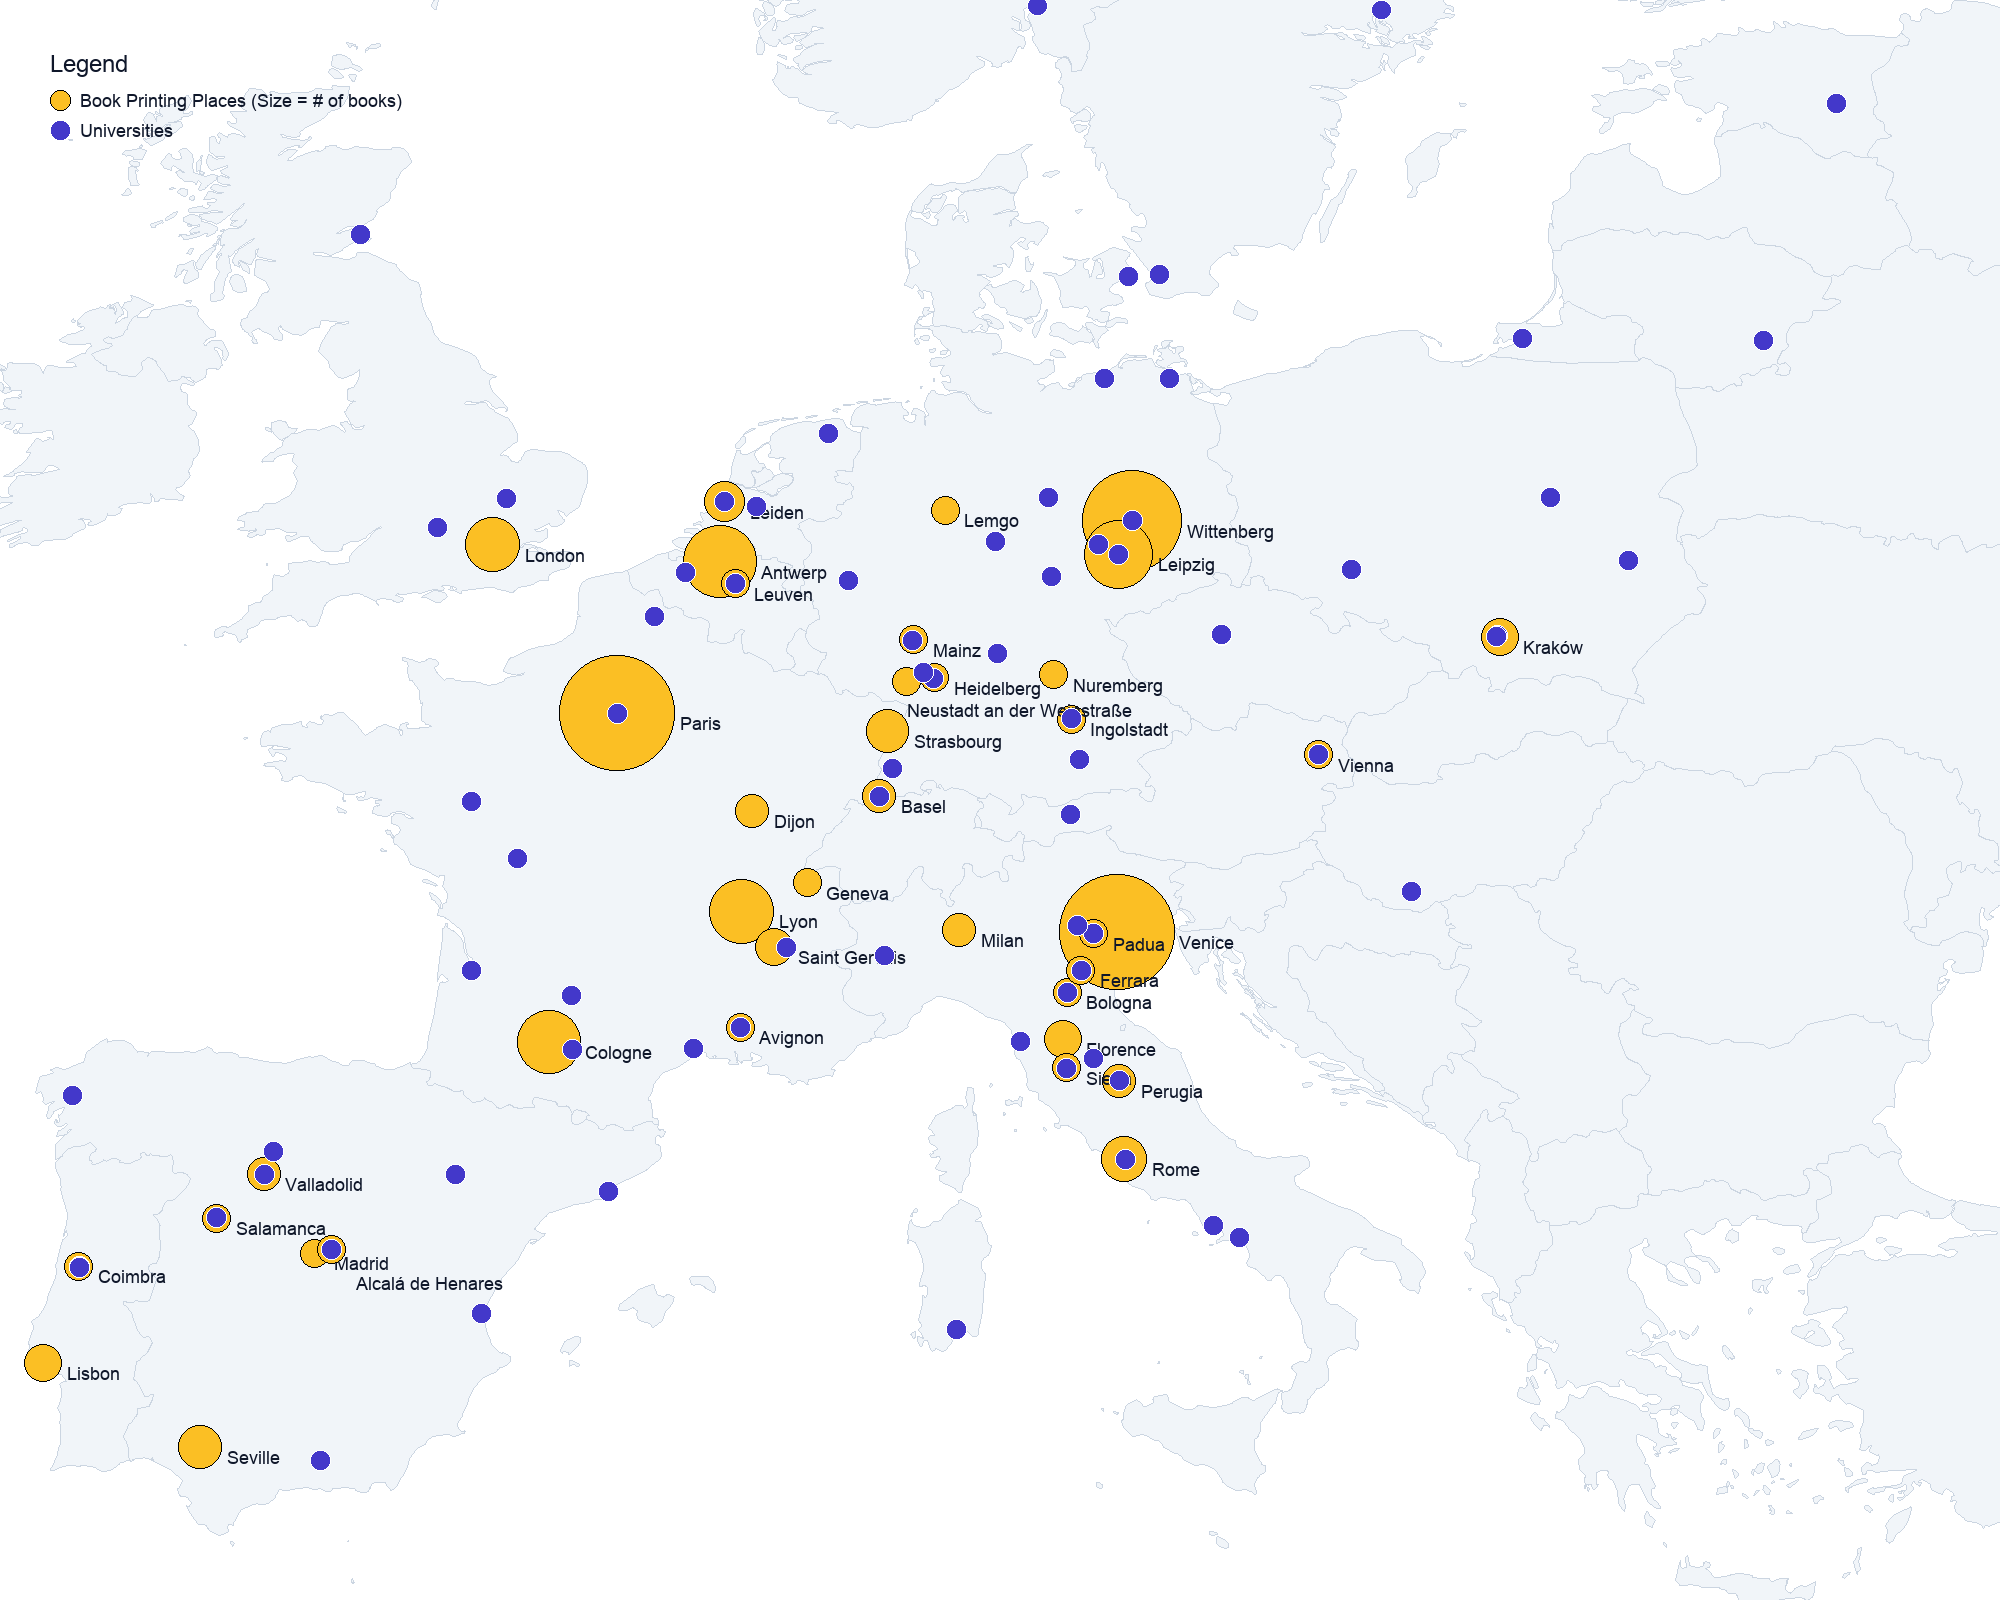

In [21]:
# Static PNG Map (Refined Bright Version)
from PIL import Image, ImageDraw, ImageFont
import json
import IPython.display
from collections import Counter
import os
import math

# === CONFIGURATION ===
LABEL_SIZE = 18 
FONT_PATH = "/System/Library/Fonts/Supplemental/Arial.ttf"
LABEL_PADDING = 3 # Pixels of buffer around each label
# =====================

LON_MIN, LON_MAX = -10, 30
LAT_MIN, LAT_MAX = 35, 60
WIDTH, HEIGHT = 2000, 1600

def project(lat, lon):
    x = (lon - LON_MIN) / (LON_MAX - LON_MIN) * WIDTH
    y = HEIGHT - (lat - LAT_MIN) / (LAT_MAX - LAT_MIN) * HEIGHT
    return x, y

def intersects(rect1, rect2, padding=0):
    r1 = (rect1[0]-padding, rect1[1]-padding, rect1[2]+padding, rect1[3]+padding)
    return not (r1[2] < rect2[0] or r1[0] > rect2[2] or r1[3] < rect2[1] or r1[1] > rect2[3])

# Colors
BG_COLOR = (255, 255, 255)
LAND_COLOR = (241, 245, 249)
BORDER_COLOR = (203, 213, 225)
BOOK_COLOR = (251, 191, 36)
UNIV_COLOR = (67, 56, 202)
LABEL_COLOR = (15, 23, 42)

try:
    font = ImageFont.truetype(FONT_PATH, LABEL_SIZE)
    font_large = ImageFont.truetype(FONT_PATH, LABEL_SIZE + 6)
except:
    font = ImageFont.load_default()
    font_large = font

with open('../../DATA/05_external_datasets/europe.geojson', 'r') as f:
    europe_geo = json.load(f)
with open('../../DATA/05_external_datasets/books_data.json', 'r') as f:
    books = json.load(f)
with open('../../DATA/05_external_datasets/universities_data.json', 'r') as f:
    univ = json.load(f)

place_counts = Counter([b['place'] for b in books])
place_coords = {b['place']: (b['lat'], b['lon']) for b in books}

img = Image.new('RGB', (WIDTH, HEIGHT), BG_COLOR)
draw = ImageDraw.Draw(img)

# 1. Draw countries
for feature in europe_geo['features']:
    geom = feature['geometry']
    polys = [geom['coordinates']] if geom['type'] == 'Polygon' else geom['coordinates']
    for poly in polys:
        ring = poly[0] if isinstance(poly[0][0], list) else poly
        points = [project(c[1], c[0]) for c in ring]
        if len(points) > 2:
            draw.polygon(points, fill=LAND_COLOR, outline=BORDER_COLOR)

# 2. Draw Books and Labels
used_rects = []
sorted_places = sorted(place_counts.items(), key=lambda x: x[1], reverse=True)

for place, count in sorted_places:
    lat, lon = place_coords[place]
    x, y = project(lat, lon)
    r = 8 + (math.sqrt(count) * 6)
    draw.ellipse([x-r, y-r, x+r, y+r], fill=BOOK_COLOR + (200,), outline=(0,0,0))
    
    label_text = place
    placed = False
    for angle in range(0, 360, 45):
        rad = math.radians(angle)
        for dist in [r + 5, r + 20, r + 40]:
            dx = math.cos(rad) * dist
            dy = math.sin(rad) * dist
            test_x, test_y = x + dx, y + dy
            if dx < 0: test_x -= draw.textlength(label_text, font=font)
            test_bbox = draw.textbbox((test_x, test_y), label_text, font=font)
            if not any(intersects(test_bbox, r_existing, LABEL_PADDING) for r_existing in used_rects):
                draw.text((test_x, test_y), label_text, fill=LABEL_COLOR, font=font)
                used_rects.append(test_bbox)
                placed = True
                break
        if placed: break

# 3. Draw Universities (On top)
for u in univ:
    x, y = project(u['lat'], u['lon'])
    r = 10
    draw.ellipse([x-r, y-r, x+r, y+r], fill=UNIV_COLOR + (140,), outline=(255,255,255))

# 4. Draw Legend (Upper Left)
lx, ly = 50, 50
draw.text((lx, ly), "Legend", fill=LABEL_COLOR, font=font_large)
ly += 40

draw.ellipse([lx, ly, lx+20, ly+20], fill=BOOK_COLOR, outline=(0,0,0))
draw.text((lx + 30, ly), "Book Printing Places (Size = # of books)", fill=LABEL_COLOR, font=font)
ly += 30

draw.ellipse([lx, ly, lx+20, ly+20], fill=UNIV_COLOR, outline=(255,255,255))
draw.text((lx + 30, ly), "Universities", fill=LABEL_COLOR, font=font)

img.save('/Users/nogashlomi/projects/nog_thesis/figures/corrections_round/not_text_paper/comparison_map_refined.png')
IPython.display.display(img)
